# Patch Basics


This notebook shows how to work with DASCore's [`Patch`](https://dascore.org/api/dascore/core/patch/Patch.html). It is a shortened version of the [DASCore's Patch tutorial](https://dascore.org/tutorial/patch.html). 

In [5]:
%%capture

# First ensure DASCore is installed. If not, install and restart the kernel.
try:
    import dascore as dc
except ImportError:
    !pip install dascore
    !pip install ipympl
    # resetart kernel
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True) #automatically restarts kernel


import numpy as np
from rich import print

# [Patch](https://dascore.org/tutorial/patch.html) 

To demonstrate the patch, we use an example seismic event recorded shown in [this study](https://www.frontiersin.org/journals/earth-science/articles/10.3389/feart.2022.907749/full).

The `Patch` is composed of:
- `coords`: the coordinates of each dimension (e.g. coord range, step, units)
- `data`: the array of measurements
- `attrs`: the non-coordinate metadata (e.g. cable id)
- `dims`: a tuple of dimension names (e.g. distance, frequency)

The `Patch` object is *immutable* which means that once a patch is created it cannot (easily) be changed. This makes it safe to share compontents between patches and simplifies parallel processing. 

In [6]:
dc.__version__

'0.1.6'

In [7]:
# The get_example_patch function is useful for loading example/test patches.
patch = dc.get_example_patch("example_event_1")

In [8]:
# Display the string representation of the patch object:
print(patch)

DASCore Patch ⚡
---------------
➤ Coordinates (distance: 601, time: 1001)
    *distance: CoordRange( min: 400 max: 1000 step: 1 shape: (601,) dtype: int64 )
    *time: CoordRange( min: 00:00:00.119999999 max: 00:00:00.219999999 step: 0.0001s shape: (1001,) dtype: 
datetime64[ns] units: s )
➤ Data (float64)
   [[  -81.   -68.   391. ...    -5.   151.   -22.]
    [ -498.   514.     3. ...    -4.   100.  -149.]
    [ -262.   486.   -79. ...   -47.    28.  -320.]
    ...
    [  333.  1057.  -641. ...   693.   163. -1426.]
    [  405.  -673.   150. ...   209.   232.  -354.]
    [  226.  -524.   378. ...    -5.  -105.  -208.]]
➤ Attributes
    cable_id: 

## `Patch` Components: Data and Dims

The data array can be accessed with `data` and updated with [`Patch.update`](https://dascore.org/tutorial/patch.html#update)

In [9]:
# Get the data array
array = patch.data

In [10]:
# Divide the data by 1_000_000 and create a new patch.
patch_new_data = patch.update(data=array / 1_000_000)

The dimensions are accessed via the `dims` attribute.

In [11]:
print(patch.dims)

('distance', 'time')

### **Exercise** (`Patch` Data)

Calculate and print following:

1. The number of samples in the data
2. The minimum and maximum value of the data

In [12]:
# Exercise (Patch Data)
array.shape

(601, 1001)

In [13]:
patch.data.size

601601

In [14]:
print(np.min(array), np.max(array))

-6102.0 5975.00146484375

## Patch Components: Attrs
Attrs contain non-dimensional metdata. Acquisition/interrogator identifiers, custom tags, etc.


In [15]:
print(patch.attrs)

PatchAttrs(
    data_type='',
    data_category='',
    data_units=None,
    instrument_id='',
    acquisition_id='',
    tag='',
    station='',
    network='',
    history=(),
    dims='distance,time',
    coords=<FrozenDict {'distance': CoordSummary(dtype='int64', min=400, max=1000, step=1, units=None), 'time': 
CoordSummary(dtype='datetime64', min=np.datetime64('1970-01-01T00:00:00.119999999'), 
max=np.datetime64('1970-01-01T00:00:00.219999999'), step=np.timedelta64(100000,'ns'), units=<Quantity(1, 
'second')>)}>,
    cable_id=np.str_('')
)

Notice the `acquisition_id` and `cable_id` are not set. We could set or update `Attrs` like so: 

In [16]:
patch_updated_attrs = patch.update_attrs(
    acquisition_id="experiment_12",
    cable_id="b202393ad",
)
print(patch_updated_attrs)

DASCore Patch ⚡
---------------
➤ Coordinates (distance: 601, time: 1001)
    *distance: CoordRange( min: 400 max: 1000 step: 1 shape: (601,) dtype: int64 )
    *time: CoordRange( min: 00:00:00.119999999 max: 00:00:00.219999999 step: 0.0001s shape: (1001,) dtype: 
datetime64[ns] units: s )
➤ Data (float64)
   [[  -81.   -68.   391. ...    -5.   151.   -22.]
    [ -498.   514.     3. ...    -4.   100.  -149.]
    [ -262.   486.   -79. ...   -47.    28.  -320.]
    ...
    [  333.  1057.  -641. ...   693.   163. -1426.]
    [  405.  -673.   150. ...   209.   232.  -354.]
    [  226.  -524.   378. ...    -5.  -105.  -208.]]
➤ Attributes
    acquisition_id: experiment_12
    cable_id: b202393ad

### **Exercise** (`Patch` Attrs)
Do the following:

1. Print the `cable_id` from the patch with updated attrs.
2. Create a new patch with a `station name` of "DAS1".

In [17]:
# Exercise (Patch Attrs)
print(patch.attrs)

PatchAttrs(
    data_type='',
    data_category='',
    data_units=None,
    instrument_id='',
    acquisition_id='',
    tag='',
    station='',
    network='',
    history=(),
    dims='distance,time',
    coords=<FrozenDict {'distance': CoordSummary(dtype='int64', min=400, max=1000, step=1, units=None), 'time': 
CoordSummary(dtype='datetime64', min=np.datetime64('1970-01-01T00:00:00.119999999'), 
max=np.datetime64('1970-01-01T00:00:00.219999999'), step=np.timedelta64(100000,'ns'), units=<Quantity(1, 
'second')>)}>,
    cable_id=np.str_('')
)

## Patch Components: Coords

`Coords` represent information about the coordinates (not coordinate systems) associated with a patch. These include, but aren't limited to, the dimensions such as 'time' and 'distance'.


In [18]:
print(patch.coords) # The coordinates and their labels. 

➤ Coordinates (distance: 601, time: 1001)
    *distance: CoordRange( min: 400 max: 1000 step: 1 shape: (601,) dtype: int64 )
    *time: CoordRange( min: 00:00:00.119999999 max: 00:00:00.219999999 step: 0.0001s shape: (1001,) dtype: 
datetime64[ns] units: s )

`Coords` objects can be accessed with [`Patch.get_coord`](https://dascore.org/api/dascore/proc/coords/get_coord.html). 

In [19]:
dist_coord = patch.get_coord("distance")

# Get the start, stop, step, and units of the distance coord
dist_start = dist_coord.min()
dist_stop = dist_coord.max()
dist_step = dist_coord.step
dist_units = dist_coord.units

# Get the underlying array data in the coordinate.
dist_array = dist_coord.values

Alternatively, [`Patch.get_array`](https://dascore.org/api/dascore/proc/coords/get_array.html) simply returns the numpy array of the coordinate. 

In [20]:
# The values of the distance dimension
dist = patch.get_array("distance")

# The value of the time dimension using a numpy datetime64 array.
time = patch.get_array("time")

# Convert the array to seconds from 1970 (floats)
time_s = dc.to_float(time)
# time_s = np.float(time)

Coordinates can be renamed using [`Patch.rename_coord`](https://dascore.org/api/dascore/proc/coords/rename_coords.html)

In [21]:
patch_renamed_coords = patch.rename_coords(distance="depth")
print(patch_renamed_coords.dims)

('depth', 'time')

Or updated using [`Patch.update_coords`](https://dascore.org/api/dascore/proc/coords/update_coords.html)

In [22]:
from dascore.units import m

# Add 12 m to the current distance values.
dist = patch.get_array("distance")
patch_new_dist = patch.update_coords(distance=(dist + 12)*m)

dist2 = patch_new_dist.get_coord("distance")

In [23]:
print(dist2)

CoordRange( min: 412 max: 1012 step: 1 shape: (601,) dtype: int64 units: m )

### **Exercise** (`Patch` Coords)

Calculate the and print following parameters:

1. The duration (time) of the patch recording using the time coordinate.
2. Reset the start of the time coordiante (e.g., 08:00, April 14, 2025).


In [24]:
# Exercise (Patch Coords)


## `Patch` [Visualization](https://dascore.org/tutorial/visualization.html)
DASCore provides visualization in the `patch.viz` namespace.


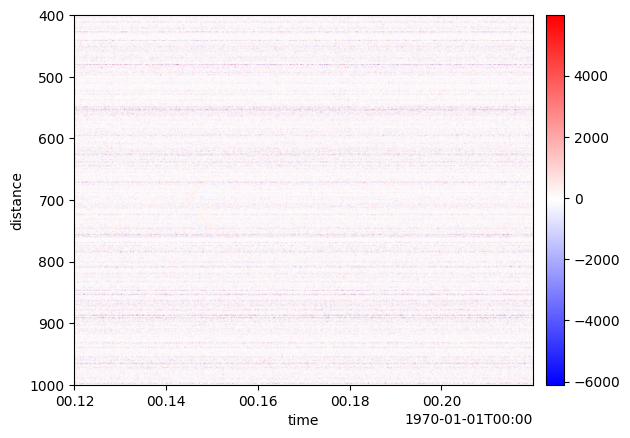

In [25]:
# The classic waterfall plot
patch.viz.waterfall();

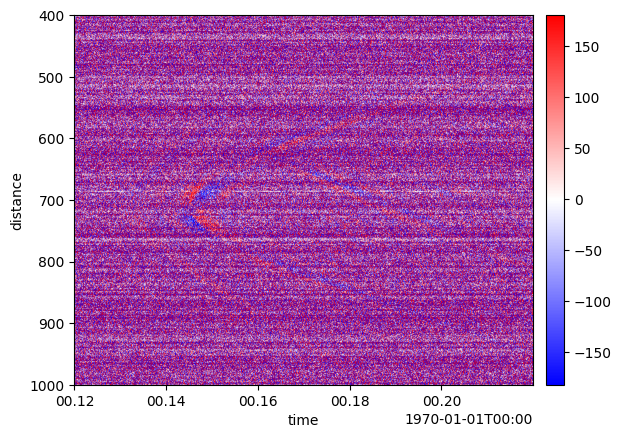

In [26]:
# Adjust the scale parameter to make the event more visible
# Try different values to see what works best
patch.viz.waterfall(scale=0.03);  # Smaller scale value increases contrast

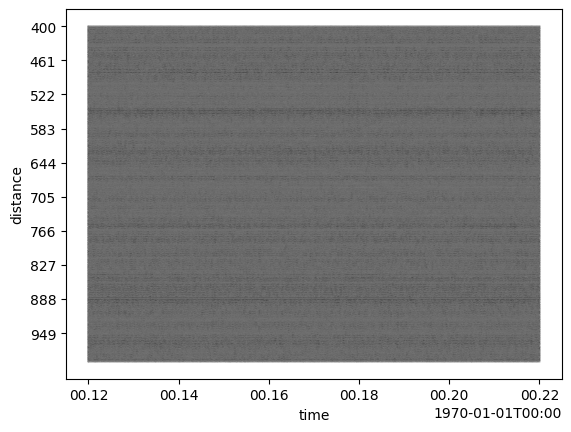

In [27]:
# A wiggle plot
patch.viz.wiggle();

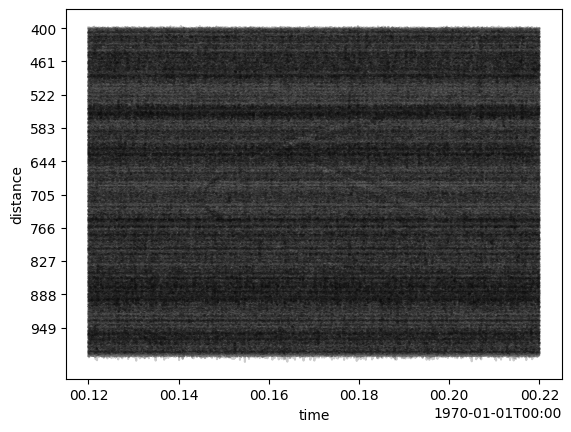

In [28]:
# A wiggle plot
patch.viz.wiggle(scale=0.1); # Smaller scale value increases contrast

## Trimming and sub-selection
[`Patch.select`](https://dascore.org/api/dascore/core/spool/DataFrameSpool/select.html) is used to trim patches. For example, to zoom in on the down-going reflection in our example patch. 

In [29]:
trimmed = patch.select(time=(.16, .22), distance =(600,800))

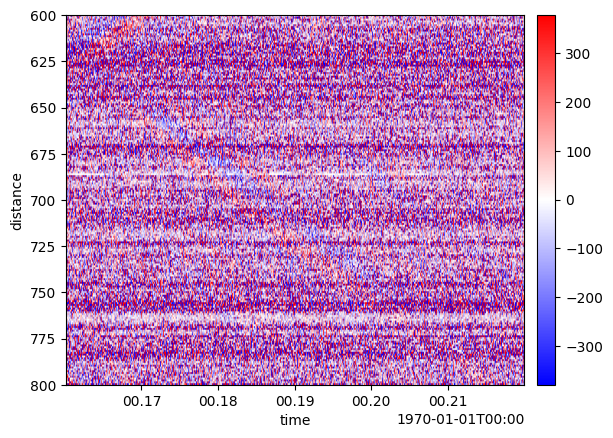

In [30]:
trimmed.viz.waterfall(scale=0.1);

Trimming can also be done via samples

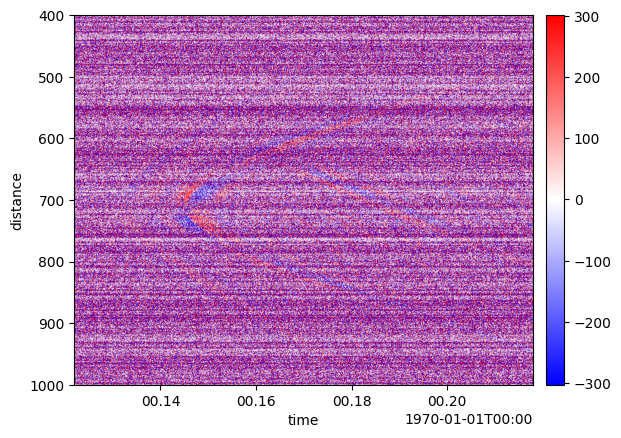

In [31]:
# Remove 20 samples from start and end of time dimension using samples=True
trimmed_patch = patch.select(time=(20, -20), samples=True)
trimmed_patch.viz.waterfall(scale=0.05);

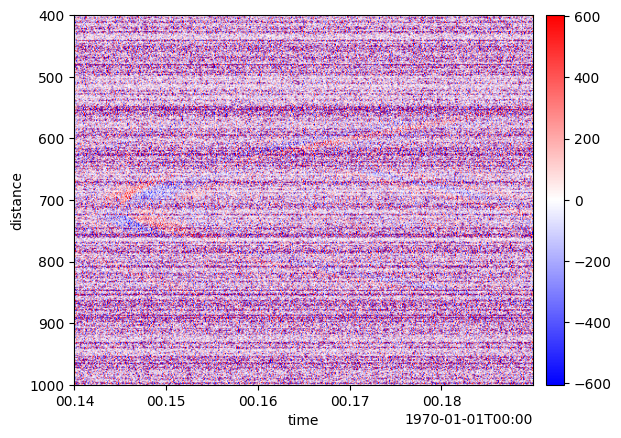

In [32]:
# Remove 0.02 seconds from start and 0.03 seconds from the end of patch using relative=True
trimmed_patch = patch.select(time=(0.02, -0.03), relative=True)
trimmed_patch.viz.waterfall(scale=0.1);

### **Exercise** (`Patch` Select)
Remove the first 10 spatial channels then the last .05 seconds. 

In [33]:
# Exercise (Patch Select)


## `Patch` [Processing](https://dascore.org/tutorial/processing.html)
DASCore provides many [processing](https://dascore.org/api/dascore/proc.html) patch methods. This section will highlight a few of these.


### [Pass Filtering](https://dascore.org/api/dascore/proc/filter/pass_filter.html)
The [`Patch.pass_filter`](https://dascore.org/api/dascore/proc/filter/pass_filter.html) method is used to apply bandpass, lowpass, and highpass SOS filters to the data along a specified dimension.

In [34]:
# apply a 100Hz to 300Hz highpass
patch_bp = patch.pass_filter(time=(100, 300))  

# apply a 300Hz lowpass
patch_lp = patch.pass_filter(time=(..., 300))  

# apply a 50Hz highpass
patch_hp = patch.pass_filter(time=(50, ...))  

### Units (time)

In [35]:
from dascore.units import Hz, s

patch = dc.get_example_patch()

# Band-pass filter between 10Hz and 40Hz
patch_filt = patch.pass_filter(time=(10*Hz, 40*Hz))

# Band-pass filter between 20s and 2s
patch_filt = patch.pass_filter(time=(2*s, 20*s))

### [Frequency-wavenumber (F-K) filter](https://dascore.org/api/dascore/proc/filter/slope_filter.html) 
The [`Patch.slope_filter`](https://dascore.org/api/dascore/proc/filter/slope_filter.html) method is used as an F-K (frequency wavenumber) filter to attenuate energy with specified apparent velocities.

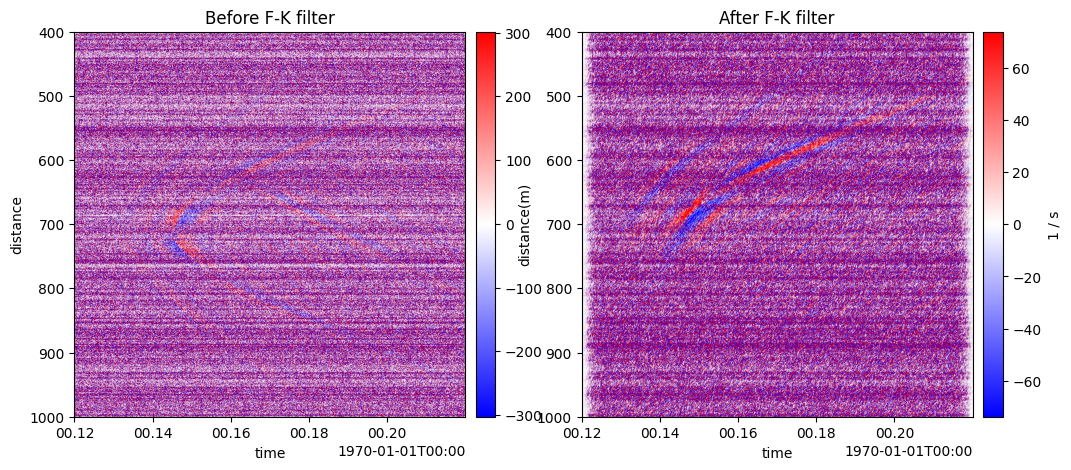

In [36]:
import matplotlib.pyplot as plt

patch = dc.get_example_patch("example_event_1")


patch_slope_fil = (
    patch.set_units("1/s", distance="m", time="s")
    .detrend("time")
    .taper(time=0.05)
    .slope_filter(filt=[2e3,2.2e3,8e3,2e4],
                directional=True,
                notch=False)
)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

patch.viz.waterfall(ax=axs[0],scale=0.05);
axs[0].set_title('Before F-K filter');

patch_slope_fil.viz.waterfall(ax=axs[1],scale=0.05);
axs[1].set_title('After F-K filter');

### **Exercise** (`Patch` processing 1)
Plot each of the pass-filtered patches. Which filtering technique did the best at enhancing the event signal? 

In [37]:
# Exercise (Patch processing 1)


### Decimate
`decimate` reduces the number of samples in the specified dimension. By default, a lowpass filter is applied to avoid aliasing.

In [38]:
# keep every 10th sample along time axis
patch_dec = patch.decimate(time=10)  

### Detrend

`Patch.detrend` applies a linear detrend along a specified dimension (axis).

In [39]:
patch_detrended = patch.detrend("time")

### Resample

Like `decimate`, `resample` is used to change the sampling rate of the patch along a specific dimension. Unlike `decimate`, however, non-integar multiples can be used.

In [40]:
patch_resamp = patch.resample(distance=15)  # change spatial sampling to 15m

### Processing methods are chained together

In [41]:
patch = dc.get_example_patch("example_event_1")

patch_proc = (
    patch.set_units("1/s", distance="m", time="s")
    .detrend("time")
    .taper(time=0.05)
    .pass_filter(time=(..., 300))
)


### **Exercise** (`Patch` processing 2)

Find some methods in the [processing module documentation](https://dascore.org/api/dascore/proc.html) and apply them to the event patch. Visualize the results. 

In [42]:
# Exercise (Patch processing 2)


### Aggregate
[`Patch.aggregate`](https://dascore.org/api/dascore/proc/aggregate/aggregate.html) performs aggregations along specified dimension(s). Shortcuts for `min`, `max`, `mean`, etc. are also provided.

In [43]:
# Use aggregate and mean to calculate the same patch.
mean_1 = patch.aggregate("time", method="mean")
mean_2 = patch.mean("time")

In [44]:
# Aggregate supports any tensor reduction operation. 
reduced = patch.aggregate("time", np.sum)
print(reduced)

DASCore Patch ⚡
---------------
➤ Coordinates (distance: 601, time: 1)
    *distance: CoordRange( min: 400 max: 1000 step: 1 shape: (601,) dtype: int64 )
    *time: CoordPartial( step: 0.0001s shape: (1,) dtype: datetime64[ns] units: s )
➤ Data (float64)
   [[-942.001]
    [-973.998]
    [-967.   ]
    ...
    [-888.998]
    [ -93.   ]
    [-426.001]]
➤ Attributes
    history: ("aggregate(dim='time',dim_reduce='empty',method='<function sum at 0x110fd8ae0>')",)
    cable_id: 

## Patch [Transformations](https://dascore.org/tutorial/transformations.html)
In addition to the processing methods, DASCore includes several patch [transformation methods](https://dascore.org/api/dascore/transform.html). This section shows some examples.

In [45]:
# Load a cleaned-up patch from the previous example.
patch = dc.get_example_patch("example_event_2")

In [46]:
# Perform a Discrete Fourier Transform (DFT) along the time axis. 
patch_fft = patch.dft("time", real=True)

In [47]:
# Integrate along time domain
patch_int = patch.integrate("time")

In [48]:
print(patch_fft), print(patch_int)

DASCore Patch ⚡
---------------
➤ Coordinates (distance: 601, ft_time: 505)
    *distance: CoordRange( min: 400 max: 1000 step: 1 shape: (601,) dtype: int64 units: m )
    *ft_time: CoordRange( min: 0.0 max: 5e+03 step: 9.92 shape: (505,) dtype: float64 units: 1 / s )
    time (): CoordRange( min: 0.0 max: 0.101 step: 0.0001 shape: (1008,) dtype: float64 units: s )
➤ Data (complex128, units: 1 ϵ)
   [[-1.130e-01+0.000e+00j  7.977e-03-1.051e-02j -1.528e-02-3.202e-03j ...
      1.237e-04-3.058e-06j  1.238e-04-1.530e-06j  1.238e-04+0.000e+00j]
    [-8.096e-02+0.000e+00j  1.398e-02-1.381e-02j -2.006e-02-1.666e-02j ...
      3.249e-05-3.318e-06j  3.261e-05-1.661e-06j  3.264e-05+0.000e+00j]
    [-8.753e-02+0.000e+00j  7.371e-03-4.549e-03j  2.679e-03-5.256e-03j ...
      2.224e-04-3.069e-06j  2.225e-04-1.536e-06j  2.225e-04+0.000e+00j]
    ...
    [-6.548e-02+0.000e+00j -1.225e-02-2.907e-02j -8.939e-02-3.164e-02j ...
     -8.807e-04-4.008e-06j -8.803e-04-2.010e-06j -8.802e-04+0.000e+00j]
    [-7.560e-03+0.000e+00j  1.382e-02-4.436e-03j -7.807e-03-1.224e-02j ...
     -4.546e-04+6.856e-06j -4.547e-04+3.430e-06j -4.548e-04+0.000e+00j]
    [-9.212e-03+0.000e+00j  1.039e-02-5.464e-03j -5.896e-03-9.545e-03j ...
     -2.009e-04+4.663e-06j -2.010e-04+2.333e-06j -2.011e-04+0.000e+00j]]
➤ Attributes
    data_units: ϵ
    history: ("update_coords(time='[0.  0.  0.  ... 0.1 0.1 0.1]')", 
"set_units(data_units='strain/s',distance='m',time='s')", "taper(time='0.05',window_type='hann')", 
"pass_filter(corners='4',time='(Ellipsis,300)',zerophase='True')", "dft(dim='time',pad='True',real='True')")
    cable_id: 

DASCore Patch ⚡
---------------
➤ Coordinates (distance: 601, time: 1001)
    *distance: CoordRange( min: 400 max: 1000 step: 1 shape: (601,) dtype: int64 units: m )
    *time: CoordRange( min: 0.0 max: 0.1 step: 0.0001 shape: (1001,) dtype: float64 units: s )
➤ Data (float64, units: 1 ϵ)
   [[ 0.000e+00  2.010e-04  4.025e-04 ... -1.133e-01 -1.132e-01 -1.131e-01]
    [ 0.000e+00 -7.739e-06 -1.876e-05 ... -8.112e-02 -8.106e-02 -8.099e-02]
    [ 0.000e+00  4.362e-04  8.839e-04 ... -8.780e-02 -8.778e-02 -8.775e-02]
    ...
    [ 0.000e+00 -2.110e-03 -4.266e-03 ... -6.516e-02 -6.484e-02 -6.457e-02]
    [ 0.000e+00 -8.740e-04 -1.770e-03 ... -6.861e-03 -6.981e-03 -7.085e-03]
    [ 0.000e+00 -3.558e-04 -7.288e-04 ... -8.824e-03 -8.916e-03 -9.000e-03]]
➤ Attributes
    data_type: strain_rate
    data_units: ϵ
    history: ("update_coords(time='[0.  0.  0.  ... 0.1 0.1 0.1]')", 
"set_units(data_units='strain/s',distance='m',time='s')", "taper(time='0.05',window_type='hann')", 
"pass_filter(corners='4',time='(Ellipsis,300)',zerophase='True')", "integrate(definite='False',dim='time')")
    cable_id: 

(None, None)

### **Exercise** (`Patch` Transformation)
Do the following to the patch above:

1. Perform a real discrete Fourier transform along the time axis
2. Get the amplitude spectra
3. Take the mean along the distance dimension
4. Select frequencies (`ft_time` dimension) less than 500 Hz
5. Plot using matplotlib and the `ft_time` dimension's values


In [49]:
# Exercise (Patch Transformation)


## `Patch` [Conversion](https://dascore.org/recipes/external_conversion.html#obspy)

Although DASCore provides a lot of the functionality needed for DFOS processing, is not intended to do absolutely everything, and some other libraries might be better suited for a particular task. In addition to making it simple to access the underlying data as shown in the [patch tutorial](https://dascore.org/tutorial/patch.html), DASCore provides convenience functions to convert data to formats used by other libraries. 

In [50]:
patch = dc.get_example_patch("example_event_1")

stream = patch.io.to_obspy()